In [26]:
#General Packages
import pandas as pd
import torch
import torch.nn.functional as F
import ast
import scipy.stats as stats
import os

#Statistical tests
import statsmodels.formula.api as smf

#Plot
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

In [27]:
directory = '../results/'

df = pd.concat(
    [pd.read_csv(os.path.join(directory, f)) for f in os.listdir(directory) if f.endswith('.csv')],
    ignore_index=True
).drop_duplicates()

In [28]:
nan_rows = df[df.isna().any(axis=1)]
df.loc[df['first_success_iter'].isna(), 'attack_successful'] = False
df['first_success_iter'] = df['first_success_iter'].fillna(1000000)

In [29]:
model_counts = df['model'].value_counts()
print(model_counts)

model
mobilenet_imagenet20_adv       11808
mobilenet_imagenet20           11808
mobilenet_imagenet20_robust    11808
resnet_imagenet20_adv          11808
resnet_imagenet20              11808
resnet_imagenet20_robust       11808
swin_imagenet20_adv            11808
swin_imagenet20                11808
swin_imagenet20_robust         11808
Name: count, dtype: int64


In [30]:
df_mobilenet_adv = df[df['model'] == 'mobilenet_imagenet20_adv'].copy()
df_resnet_adv    = df[df['model'] == 'resnet_imagenet20_adv'].copy()
df_swin_adv      = df[df['model'] == 'swin_imagenet20_adv'].copy()

df_mobilenet_robust = df[df['model'] == 'mobilenet_imagenet20_robust'].copy()
df_resnet_robust    = df[df['model'] == 'resnet_imagenet20_robust'].copy()
df_swin_robust      = df[df['model'] == 'swin_imagenet20_robust'].copy()

df_mobilenet_base = df[df['model'] == 'mobilenet_imagenet20'].copy()
df_resnet_base   = df[df['model'] == 'resnet_imagenet20'].copy()
df_swin_base      = df[df['model'] == 'swin_imagenet20'].copy()

In [31]:
df_base = pd.concat([df_mobilenet_base, df_resnet_base, df_swin_base], ignore_index=True)
df_robust = pd.concat([df_mobilenet_robust, df_resnet_robust, df_swin_robust], ignore_index=True)
df_adv = pd.concat([df_mobilenet_adv, df_resnet_adv, df_swin_adv], ignore_index=True)


In [32]:
df_total = pd.concat([df_base,df_robust, df_adv],ignore_index=True)

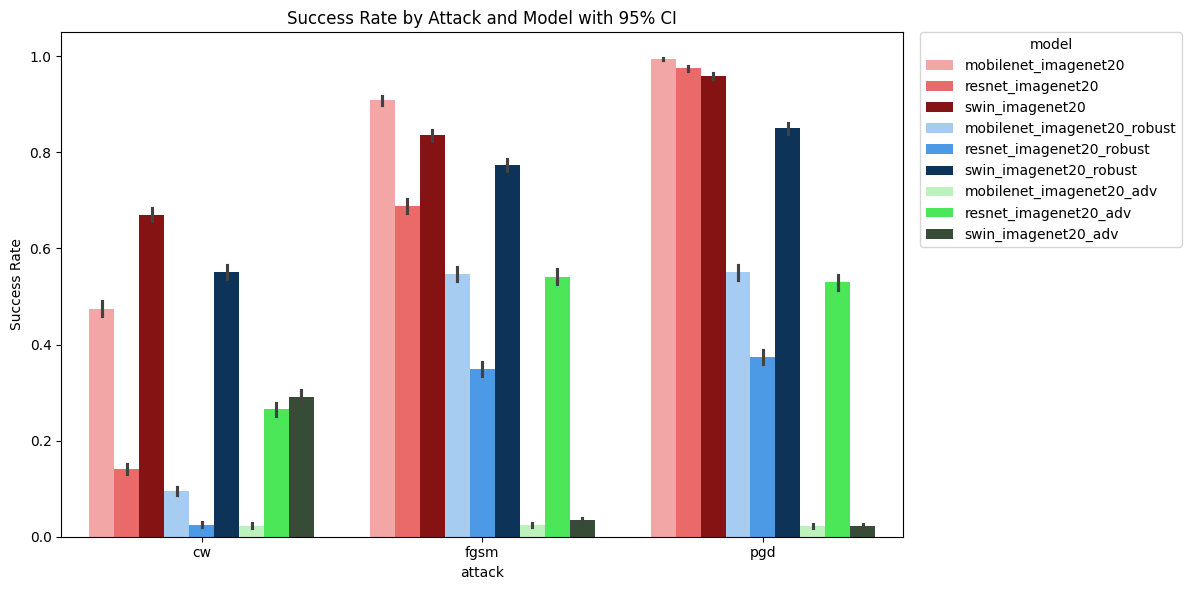

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_total,
    x="attack",
    y="attack_successful",
    hue="model",
    errorbar=('ci', 95),
    estimator=lambda x: x.mean(),
    palette=custom_palette,
    hue_order=model_order,
    ax=ax,
)

# shrink the plot area 
fig.subplots_adjust(right=0.75)

# place the legend
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    ncol=1,             
    title='model'
)

ax.set_title("Success Rate by Attack and Model with 95% CI")
ax.set_ylabel("Success Rate")
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


In [24]:
psnr_robust = df_base.groupby('attack')['psnr_score'].mean()
print(psnr_robust)

psnr_robust = df_robust.groupby('attack')['psnr_score'].mean()
print(psnr_robust)

psnr_robust = df_adv.groupby('attack')['psnr_score'].mean()
print(psnr_robust)


attack
cw      75.263213
fgsm    85.846883
pgd     91.256196
Name: psnr_score, dtype: float64
attack
cw      72.672418
fgsm    85.295767
pgd     86.761329
Name: psnr_score, dtype: float64
attack
cw      73.448618
fgsm    84.937477
pgd     86.961739
Name: psnr_score, dtype: float64


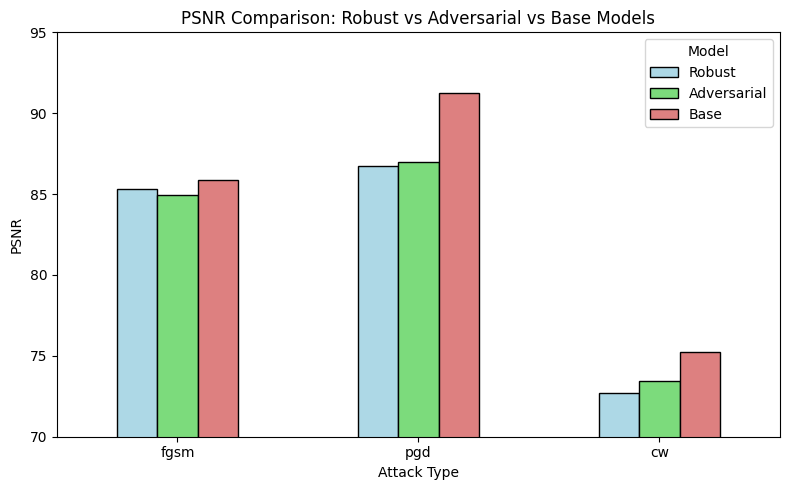

In [ ]:
psnr_robust = pd.Series({
    'cw': 72.672418,
    'fgsm': 85.295767,
    'pgd': 86.761329
}, name="Robust")

psnr_adv = pd.Series({
    'cw': 73.448618,
    'fgsm': 84.937477,
    'pgd': 86.961739
}, name="Adversarial")

psnr_success = pd.Series({
    'cw': 75.263213,
    'fgsm': 85.846883,
    'pgd': 91.256196
}, name="Base")

# Combine and reorder
df = pd.concat([psnr_robust, psnr_adv, psnr_success], axis=1)
df.columns = ["Robust", "Adversarial", "Base"]

# Reorder index
attack_order = ["fgsm", "pgd", "cw"]
df = df.loc[attack_order]

# Plotting
ax = df.plot(
    kind="bar", 
    figsize=(8, 5), 
    color=["#ADD8E6","#7CDB7C", "#DD8080"],  # Light green and light red
    edgecolor="black"
)

# Formatting
plt.title("PSNR Comparison: Robust vs Adversarial vs Base Models")
plt.ylabel("PSNR")
plt.xlabel("Attack Type")
plt.xticks(rotation=0)
plt.ylim(70, 95)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


# PSNR mixed effects tests

In [ ]:
model = smf.mixedlm(
    "psnr_score ~ model * attack",     
    df_total,
    groups="dataset_index"                 
)
result = model.fit()

# Print the summary
print(result.summary())


                             Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             psnr_score  
No. Observations:               106272              Method:                         REML        
No. Groups:                     3936                Scale:                          1.2574      
Min. group size:                27                  Log-Likelihood:                 -165859.9612
Max. group size:                27                  Converged:                      Yes         
Mean group size:                27.0                                                            
------------------------------------------------------------------------------------------------
                                                    Coef.  Std.Err.    z     P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                           75.583  

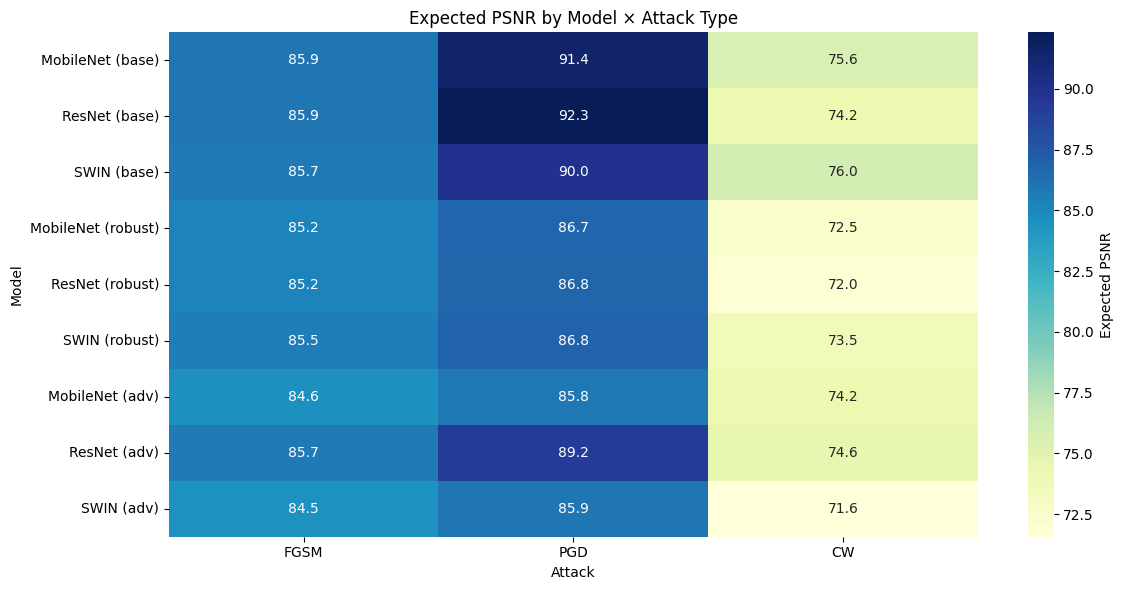

In [ ]:
intercept = 75.583
fgsm_main = 10.292
pgd_main = 15.862

# Expected values
data = [
    # FGSM, PGD, CW
    [intercept + fgsm_main, intercept + pgd_main, intercept],  # Base MobileNet
    [intercept - 1.356 + fgsm_main + 1.409, intercept - 1.356 + pgd_main + 2.237, intercept - 1.356],  # Base ResNet
    [intercept + 0.398 + fgsm_main - 0.533, intercept + 0.398 + pgd_main -1.843 , intercept + 0.398],  # Base SWIN
    [intercept - 3.054 + fgsm_main + 2.409, intercept - 3.054 + pgd_main - 1.705, intercept - 3.054],  # Robust MobileNet
    [intercept - 3.624 + fgsm_main + 2.948, intercept - 3.624 + pgd_main - 1.055, intercept - 3.624],  # Robust ResNet
    [intercept - 2.052 + fgsm_main + 1.638, intercept - 2.052 + pgd_main - 2.558, intercept - 2.052],  # Robust SWIN
    [intercept - 1.377 + fgsm_main + 0.063, intercept - 1.377 + pgd_main - 4.235, intercept - 1.377],  # Adv MobileNet
    [intercept - 1.010 + fgsm_main + 0.868, intercept - 1.010 + pgd_main - 1.236, intercept - 1.010],  # Adv ResNet
    [intercept - 4.015 + fgsm_main + 2.665, intercept - 4.015 + pgd_main - 1.574, intercept - 4.015],  # Adv SWIN
]

# Labels
models = [
    "MobileNet (base)", "ResNet (base)", "SWIN (base)",
    "MobileNet (robust)", "ResNet (robust)", "SWIN (robust)",
    "MobileNet (adv)", "ResNet (adv)", "SWIN (adv)"
]
attacks = ["FGSM", "PGD", "CW"]

# Create DataFrame
df = pd.DataFrame(data, index=models, columns=attacks)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Expected PSNR'})
plt.title("Expected PSNR by Model × Attack Type")
plt.ylabel("Model")
plt.xlabel("Attack")
plt.tight_layout()
plt.show()


# KL divergence

In [39]:
df_total["original_probs"] = df_total["original_probs"].apply(ast.literal_eval)
df_total["adversarial_probs"] = df_total["adversarial_probs"].apply(ast.literal_eval)

In [40]:
def kl_divergence(p, q):
    # Convert to tensors
    p = torch.tensor(p, dtype=torch.float32)
    q = torch.tensor(q, dtype=torch.float32)

    # Add small epsilon to avoid log(0)
    epsilon = 1e-8
    p = p + epsilon
    q = q + epsilon

    return F.kl_div(q.log(), p, reduction="sum").item()  

In [41]:
df_total["kl_divergence"] = df_total.apply(lambda row: kl_divergence(row["original_probs"], row["adversarial_probs"]), axis=1)


In [42]:
print(df_total.groupby("attack")["kl_divergence"].mean())

attack
cw      1.501697
fgsm    2.395316
pgd     3.948290
Name: kl_divergence, dtype: float64


In [43]:
model = smf.mixedlm("kl_divergence ~ model * attack", data=df_total, groups=df_total["dataset_index"])
result = model.fit()

print(result.summary())

                             Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             kl_divergence
No. Observations:              106272              Method:                         REML         
No. Groups:                    3936                Scale:                          6.8226       
Min. group size:               27                  Log-Likelihood:                 -256087.8008 
Max. group size:               27                  Converged:                      Yes          
Mean group size:               27.0                                                             
------------------------------------------------------------------------------------------------
                                                    Coef.  Std.Err.    z     P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                            2.101  

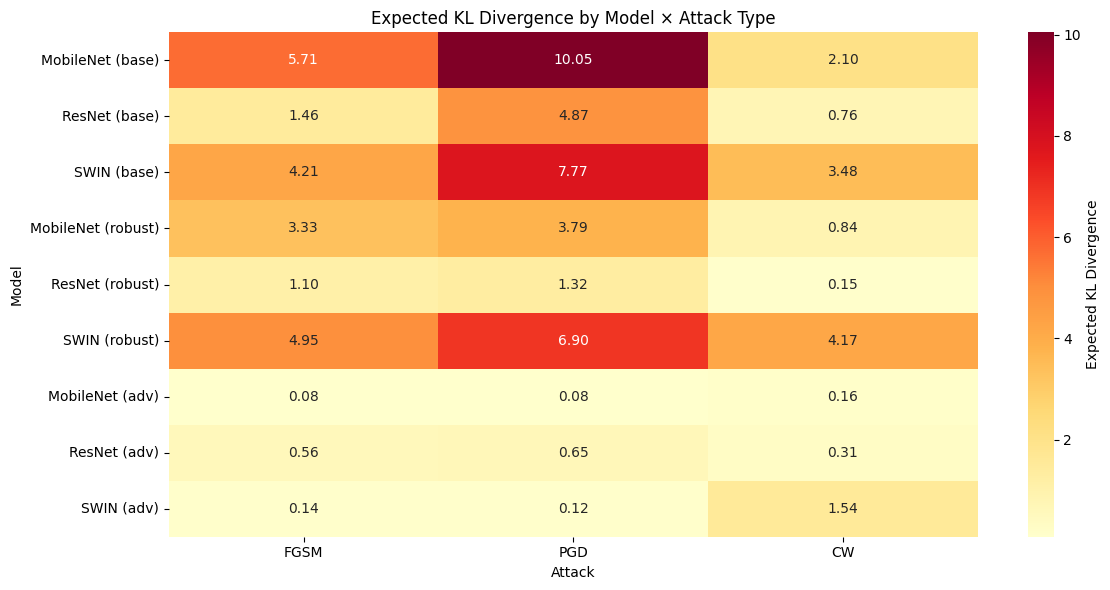

In [ ]:
# KL divergence values from Mixed Linear Model coefficients
intercept = 2.101
fgsm_main = 3.607
pgd_main = 7.947

data = [
    # FGSM, PGD, CW
    [intercept + fgsm_main, intercept + pgd_main, intercept],  # MobileNet (base)
    [intercept - 1.341 + fgsm_main - 2.905, intercept - 1.341 + pgd_main - 3.842, intercept - 1.341],  # ResNet (base)
    [intercept + 1.383 + fgsm_main - 2.878, intercept + 1.383 + pgd_main - 3.663, intercept + 1.383],  # SWIN (base)
    [intercept - 1.265 + fgsm_main - 1.111, intercept - 1.265 + pgd_main - 4.995, intercept - 1.265],  # Robust MobileNet
    [intercept - 1.951 + fgsm_main - 2.655, intercept - 1.951 + pgd_main - 6.781, intercept - 1.951],  # Robust ResNet
    [intercept + 2.068 + fgsm_main - 2.825, intercept + 2.068 + pgd_main - 5.220, intercept + 2.068],  # Robust SWIN
    [intercept - 1.939 + fgsm_main - 3.689, intercept - 1.939 + pgd_main - 8.030, intercept - 1.939],  # Adv MobileNet
    [intercept - 1.790 + fgsm_main - 3.353, intercept - 1.790 + pgd_main - 7.612, intercept - 1.790],  # Adv ResNet
    [intercept - 0.563 + fgsm_main - 5.006, intercept - 0.563 + pgd_main - 9.361, intercept - 0.563],  # Adv SWIN
]

models = [
    "MobileNet (base)", "ResNet (base)", "SWIN (base)",
    "MobileNet (robust)", "ResNet (robust)", "SWIN (robust)",
    "MobileNet (adv)", "ResNet (adv)", "SWIN (adv)"
]
attacks = ["FGSM", "PGD", "CW"]

# Create DataFrame
df = pd.DataFrame(data, index=models, columns=attacks)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Expected KL Divergence'})
plt.title("Expected KL Divergence by Model × Attack Type")
plt.ylabel("Model")
plt.xlabel("Attack")
plt.tight_layout()
plt.show()
